Import de bibliotecas

In [1]:
import pandas as pd
import numpy as np

# Carregamento e Diagnóstico Inicial dos nosso dados

In [2]:
# Carregando a base de dados
df = pd.read_csv("Obesity.csv")

In [3]:
# Visualização das primeiras linhas do dataset
print("--- Primeiras 5 linhas do Dataset ---")
df.head()

--- Primeiras 5 linhas do Dataset ---


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
# Diagnóstico de Estrutura e Valores Faltantes (Nulos)
print("\n--- Informações do Dataset (Tipos e Nulos) ---")
print(df.info())


--- Informações do Dataset (Tipos e Nulos) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null 

In [5]:
# Estatística Descritiva das Variáveis Numéricas
print("\n--- Resumo Estatístico (Variáveis Numéricas) ---")
display(df.describe().T)


--- Resumo Estatístico (Variáveis Numéricas) ---


,count,mean,std,min,25%,50%,75%,max
Age,2111.0,24.312600,6.345968,14.00,19.947192,22.777890,26.000000,61.00
Height,2111.0,1.701677,0.093305,1.45,1.630000,1.700499,1.768464,1.98
Weight,2111.0,86.586058,26.191172,39.00,65.473343,83.000000,107.430682,173.00
FCVC,2111.0,2.419043,0.533927,1.00,2.000000,2.385502,3.000000,3.00
NCP,2111.0,2.685628,0.778039,1.00,2.658738,3.000000,3.000000,4.00
CH2O,2111.0,2.008011,0.612953,1.00,1.584812,2.000000,2.477420,3.00
FAF,2111.0,1.010298,0.850592,0.00,0.124505,1.000000,1.666678,3.00
TUE,2111.0,0.657866,0.608927,0.00,0.000000,0.625350,1.000000,2.00


In [6]:
# Distribuição da nossa Variável Alvo (Target)
print("\n--- Distribuição da Variável Alvo: Obesity ---")
print(df['Obesity'].value_counts(normalize=True) * 100)


--- Distribuição da Variável Alvo: Obesity ---
Obesity
Obesity_Type_I         16.627191
Obesity_Type_III       15.348176
Obesity_Type_II        14.069162
Overweight_Level_I     13.737565
Overweight_Level_II    13.737565
Normal_Weight          13.595452
Insufficient_Weight    12.884889
Name: proportion, dtype: float64


# Engenharia de Atributos

In [7]:
# Criando uma cópia da base para não perder os dados originais
df_obesidade_tratado = df.copy()

In [8]:
# Criação de novos atributos - IMC (Índice de massa corporal) - Peso / (altura²)
df_obesidade_tratado['IMC'] = df_obesidade_tratado['Weight'] / (df_obesidade_tratado['Height'] ** 2)

df_obesidade_tratado.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,IMC
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight,24.386526
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,24.238227
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight,23.765432
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I,26.851852
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381


### Tratamento de variáveis categóricas (Encoding)

In [9]:
# Variáveis Binárias (Sim/Não ou Gênero) - female = 0 / male = 1
binary_cols = ['Gender', 'family_history', 'FAVC', 'SMOKE', 'SCC']
for col in binary_cols:
    if df_obesidade_tratado[col].dtype == 'object':
        df_obesidade_tratado[col] = df_obesidade_tratado[col].astype('category').cat.codes

df_obesidade_tratado.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,IMC
0,0,21.0,1.62,64.0,1,0,2.0,3.0,Sometimes,0,2.0,0,0.0,1.0,no,Public_Transportation,Normal_Weight,24.386526
1,0,21.0,1.52,56.0,1,0,3.0,3.0,Sometimes,1,3.0,1,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,24.238227
2,1,23.0,1.80,77.0,1,0,2.0,3.0,Sometimes,0,2.0,0,2.0,1.0,Frequently,Public_Transportation,Normal_Weight,23.765432
3,1,27.0,1.80,87.0,0,0,3.0,3.0,Sometimes,0,2.0,0,2.0,0.0,Frequently,Walking,Overweight_Level_I,26.851852
4,1,22.0,1.78,89.8,0,0,2.0,1.0,Sometimes,0,2.0,0,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381


In [10]:
# Variáveis Ordinais (Intensidade de hábitos)
# no = 0, sometimes = 1, frequently = 2, always = 3

# Usando mapeamento com letras minúsculas/maiúsculas flexíveis
df_obesidade_tratado['CAEC'] = df_obesidade_tratado['CAEC'].str.lower().map({'no': 0, 'sometimes': 1, 'frequently': 2, 'always': 3})
df_obesidade_tratado['CALC'] = df_obesidade_tratado['CALC'].str.lower().map({'no': 0, 'sometimes': 1, 'frequently': 2, 'always': 3})

df_obesidade_tratado.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,IMC
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,Public_Transportation,Normal_Weight,24.386526
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,Public_Transportation,Normal_Weight,24.238227
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,Public_Transportation,Normal_Weight,23.765432
3,1,27.0,1.80,87.0,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,Walking,Overweight_Level_I,26.851852
4,1,22.0,1.78,89.8,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,Public_Transportation,Overweight_Level_II,28.342381


In [11]:
#Verificando a distribuição da variável "Meio de transporte"
print(df_obesidade_tratado['MTRANS'].value_counts(normalize=True) * 100)

MTRANS
Public_Transportation    74.846045
Automobile               21.648508
Walking                   2.652771
Motorbike                 0.521080
Bike                      0.331596
Name: proportion, dtype: float64


In [12]:
# Variáveis Nominais (Meio de Transporte) -> Criando colunas dummies (0 ou 1)
df_obesidade_tratado = pd.get_dummies(df_obesidade_tratado, columns=['MTRANS'], drop_first=True, dtype=int)

df_obesidade_tratado.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,...,SCC,FAF,TUE,CALC,Obesity,IMC,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1,0,...,0,0.0,1.0,0,Normal_Weight,24.386526,0,0,1,0
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1,1,...,1,3.0,0.0,1,Normal_Weight,24.238227,0,0,1,0
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1,0,...,0,2.0,1.0,2,Normal_Weight,23.765432,0,0,1,0
3,1,27.0,1.80,87.0,0,0,3.0,3.0,1,0,...,0,2.0,0.0,2,Overweight_Level_I,26.851852,0,0,0,1
4,1,22.0,1.78,89.8,0,0,2.0,1.0,1,0,...,0,0.0,0.0,1,Overweight_Level_II,28.342381,0,0,1,0


In [13]:
# Garantindo que nenhum dado virou nulo por erro de mapeamento
print("--- Checagem de valores nulos após mapeamento ---")
print(df_obesidade_tratado[['CAEC', 'CALC']].isna().sum())

--- Checagem de valores nulos após mapeamento ---
CAEC    0
CALC    0
dtype: int64


In [14]:
# Visualizçaão do Dataset pronto
print("\n--- Visualização do Dataset Pronto ('df_obesidade_tratado') ---")
display(df_obesidade_tratado.head())


--- Visualização do Dataset Pronto ('df_obesidade_tratado') ---


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,...,SCC,FAF,TUE,CALC,Obesity,IMC,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1,0,...,0,0.0,1.0,0,Normal_Weight,24.386526,0,0,1,0
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1,1,...,1,3.0,0.0,1,Normal_Weight,24.238227,0,0,1,0
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1,0,...,0,2.0,1.0,2,Normal_Weight,23.765432,0,0,1,0
3,1,27.0,1.80,87.0,0,0,3.0,3.0,1,0,...,0,2.0,0.0,2,Overweight_Level_I,26.851852,0,0,0,1
4,1,22.0,1.78,89.8,0,0,2.0,1.0,1,0,...,0,0.0,0.0,1,Overweight_Level_II,28.342381,0,0,1,0


# Utilizando Random Forest como teste 1 de Modelo de Machine Learning

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [16]:
# Separando as variáveis
# 'X' são as características do paciente (features) e 'y' é o diagnóstico (target)
X = df_obesidade_tratado.drop(columns=['Obesity']) # Removemos a resposta certa
y = df_obesidade_tratado['Obesity']

# Dividindo o modelo em treino e teste (80% para treinar, 20% para testar a assertividade)
# O stratify=y garante que as 7 classes fiquem igualmente distribuídas nos dois grupos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Configuração e Treinamento do modelo
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=12)
model_rf.fit(X_train, y_train)

# Prediação e avaliação do modelo
y_pred = model_rf.predict(X_test)

# Mapeando a acurácia (assertividade) global
acuracia = accuracy_score(y_test, y_pred)
print(f"Assertividade Global do Modelo: {acuracia * 100:.2f}%\n")

# Relatório detalhado por categoria
print("--- Relatório de Classificação por Categoria ---")
print(classification_report(y_test, y_pred))

Assertividade Global do Modelo: 99.29%

--- Relatório de Classificação por Categoria ---
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        54
      Normal_Weight       0.97      1.00      0.98        58
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       1.00      0.98      0.99        58
Overweight_Level_II       1.00      1.00      1.00        58

           accuracy                           0.99       423
          macro avg       0.99      0.99      0.99       423
       weighted avg       0.99      0.99      0.99       423



Ao entregar para o modelo peso, altura e IMC já calculado, ele funcionou basicamente como uma "calculadora gourmet". O ideal é tentarmos prever o risco usando os hábitos, ou entender o comportamento das outras variáveis de forma independente.

Para isso, vamos fazer o teste do modelo removendo essas variáveis e entender como o modelo vai funcionar, e também para não causar overfitting ao modelo (ele vai decorar, em vez de aprender).

In [17]:
# Novo processo de separação, removendo os facilitadores diretos para o modelo: IMC, altura e peso
X_clinico = df_obesidade_tratado.drop(columns=['Obesity', 'IMC', 'Weight', 'Height'])
y_clinico = df_obesidade_tratado['Obesity']

# Divisão de treino e teste
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clinico, y_clinico, test_size=0.20, random_state=42, stratify=y_clinico)

# Treinamento do modelo
model_rf_clinico = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=12)
model_rf_clinico.fit(X_train_c, y_train_c)

# Predição e Avaliação
y_pred_c = model_rf_clinico.predict(X_test_c)

acuracia_c = accuracy_score(y_test_c, y_pred_c)
print(f"Assertividade Baseada APENAS em Hábitos e Genética: {acuracia_c * 100:.2f}%\n")

print("--- Novo Relatório Clínico (Sem Peso/Altura/IMC) ---")
print(classification_report(y_test_c, y_pred_c))

Assertividade Baseada APENAS em Hábitos e Genética: 86.76%

--- Novo Relatório Clínico (Sem Peso/Altura/IMC) ---
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.91      0.93        54
      Normal_Weight       0.67      0.81      0.73        58
     Obesity_Type_I       0.83      0.84      0.84        70
    Obesity_Type_II       0.93      0.93      0.93        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.81      0.76      0.79        58
Overweight_Level_II       0.91      0.83      0.86        58

           accuracy                           0.87       423
          macro avg       0.87      0.87      0.87       423
       weighted avg       0.87      0.87      0.87       423



Fazendo um novo teste mantendo o peso e a altura, mas retirando o IMC calculado, assim, o modelo precisará aprender sozinho a fórmula do IMC sem trazer um resultado "decorado".

O modelo irá cruzar o peso e a altura com o comportamento e genética dos pacientes, e vai aprender sozinho.

In [18]:
# Separando as variáveis mantendo Weight e Height, mas tirando o IMC
X_final = df_obesidade_tratado.drop(columns=['Obesity', 'IMC'])
y_final = df_obesidade_tratado['Obesity']

# Divisão treino e teste
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_final, y_final, test_size=0.20, random_state=42, stratify=y_final)

# Treinamento do modelo
model_rf_final = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=12)
model_rf_final.fit(X_train_f, y_train_f)

# Predição e avaliação
y_pred_f = model_rf_final.predict(X_test_f)

acuracia_f = accuracy_score(y_test_f, y_pred_f)
print(f"Assertividade do Modelo Final (Visão Hospitalar Completa): {acuracia_f * 100:.2f}%\n")

print("--- Relatório do Modelo Final ---")
print(classification_report(y_test_f, y_pred_f))

Assertividade do Modelo Final (Visão Hospitalar Completa): 95.04%

--- Relatório do Modelo Final ---
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.94      0.97        54
      Normal_Weight       0.82      0.93      0.87        58
     Obesity_Type_I       0.97      0.97      0.97        70
    Obesity_Type_II       0.98      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.91      0.88      0.89        58
Overweight_Level_II       0.98      0.95      0.96        58

           accuracy                           0.95       423
          macro avg       0.95      0.95      0.95       423
       weighted avg       0.95      0.95      0.95       423



Modelo final definido. Vamos manter o peso e altura, e não vamos entregar o IMC calculado!

Agora vamos extrair a importancia dos atributos. Isso irá nos ajudar a encontrar o caminho das pedras para a apresentação de gráficos ao hospital e médicos.

/tmp/ipykernel_1410/465010254.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Atributo', data=df_importancia, palette='viridis')


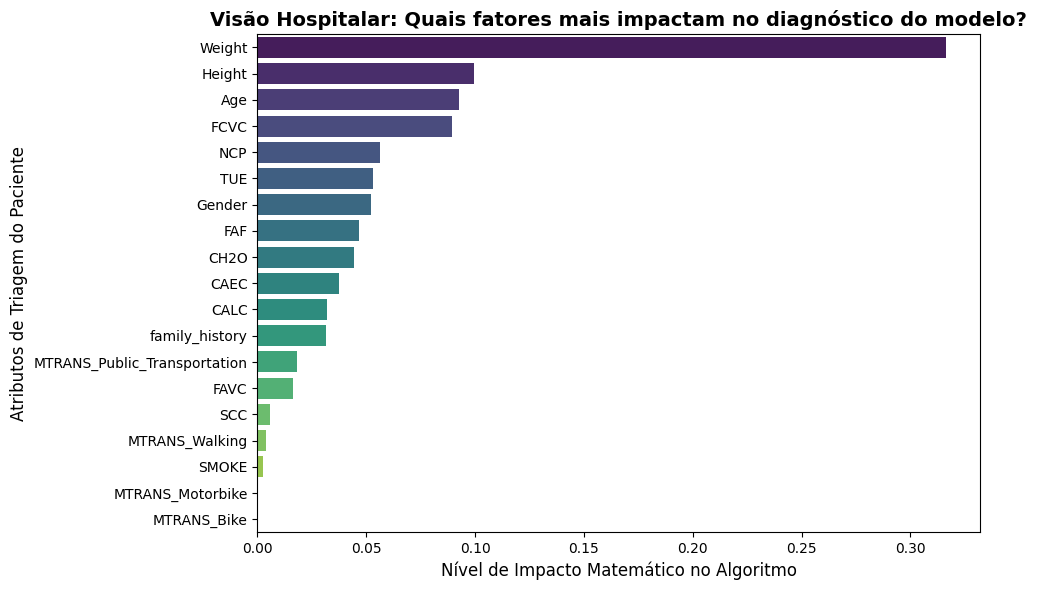

--- Top 5 Fatores Mais Determinantes na Triagem ---
Atributo  Importancia
  Weight     0.316121
  Height     0.099697
     Age     0.092851
    FCVC     0.089475
     NCP     0.056195


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extraindo a importância das variáveis do modelo final
importances = model_rf_final.feature_importances_
features = X_final.columns

# Criando o dataframe de Negócio
df_importancia = pd.DataFrame({'Atributo': features, 'Importancia': importances})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# Plotando o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Atributo', data=df_importancia, palette='viridis')

plt.title('Visão Hospitalar: Quais fatores mais impactam no diagnóstico do modelo?', fontsize=14, fontweight='bold')
plt.xlabel('Nível de Impacto Matemático no Algoritmo', fontsize=12)
plt.ylabel('Atributos de Triagem do Paciente', fontsize=12)
plt.tight_layout()
plt.show()

# Exibindo o top 5 fatores críticos
print("--- Top 5 Fatores Mais Determinantes na Triagem ---")
print(df_importancia.head(5).to_string(index=False))

# Utilizando lightGBM como teste 2 de Modelo de Machine Learning

In [20]:
from lightgbm import LGBMClassifier

# Configuração e Treinamento do Modelo LightGBM
# Usamos os mesmos dados de treino (X_train_f, y_train_f) do modelo anterior
model_lgb = LGBMClassifier(n_estimators=100, random_state=42, max_depth=8, learning_rate=0.05, verbose=-1)
model_lgb.fit(X_train_f, y_train_f)

# Prediação e Avaliação
y_pred_lgb = model_lgb.predict(X_test_f)

acuracia_lgb = accuracy_score(y_test_f, y_pred_lgb)
print(f"Assertividade do LightGBM: {acuracia_lgb * 100:.2f}%")
print(f"(Para lembrar: A assertividade do Random Forest foi: {acuracia_f * 100:.2f}%)\n")

print("--- Relatório do Modelo LightGBM ---")
print(classification_report(y_test_f, y_pred_lgb))

Assertividade do LightGBM: 95.74%
(Para lembrar: A assertividade do Random Forest foi: 95.04%)

--- Relatório do Modelo LightGBM ---
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.93      0.95        54
      Normal_Weight       0.85      0.97      0.90        58
     Obesity_Type_I       0.99      0.96      0.97        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.95      0.90      0.92        58
Overweight_Level_II       0.97      0.97      0.97        58

           accuracy                           0.96       423
          macro avg       0.96      0.96      0.96       423
       weighted avg       0.96      0.96      0.96       423



/tmp/ipykernel_1410/2353317403.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Atributo', data=df_imp_lgb, palette='mako')


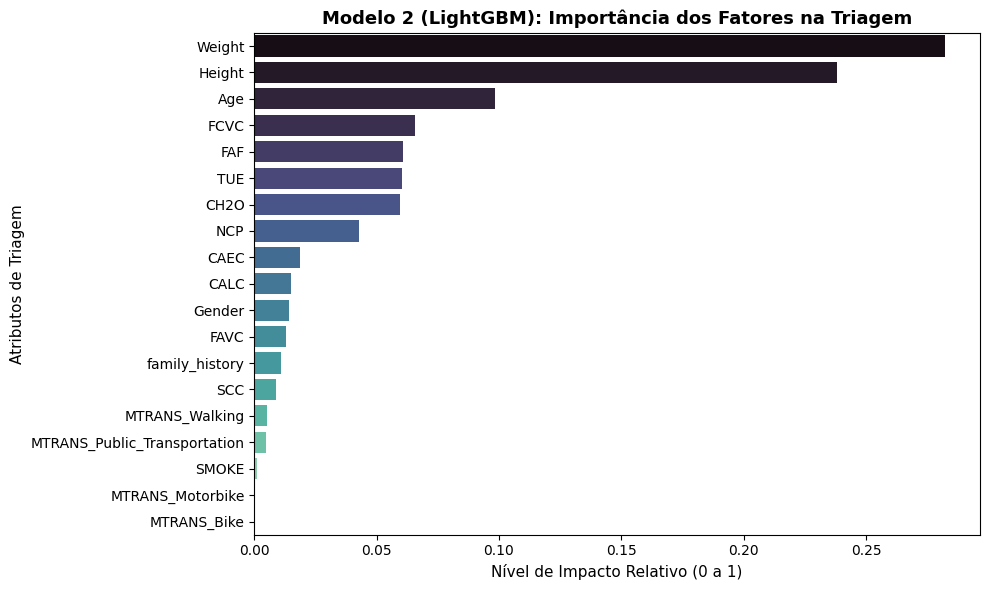

--- [LightGBM] Top 5 Fatores Mais Determinantes ---
Atributo  Importancia
  Weight     0.282464
  Height     0.238301
     Age     0.098434
    FCVC     0.065862
     FAF     0.060641


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.inspection import permutation_importance


importances_lgb = model_lgb.feature_importances_
# Normalizando a escala do LightGBM para somar 1 (ou 100%) igual ao Random Forest
importances_lgb_normalized = importances_lgb / importances_lgb.sum()

df_imp_lgb = pd.DataFrame({'Atributo': X_final.columns, 'Importancia': importances_lgb_normalized})
df_imp_lgb = df_imp_lgb.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Atributo', data=df_imp_lgb, palette='mako')
plt.title('Modelo 2 (LightGBM): Importância dos Fatores na Triagem', fontsize=13, fontweight='bold')
plt.xlabel('Nível de Impacto Relativo (0 a 1)', fontsize=11)
plt.ylabel('Atributos de Triagem', fontsize=11)
plt.tight_layout()
plt.show()

print("--- [LightGBM] Top 5 Fatores Mais Determinantes ---")
print(df_imp_lgb.head(5).to_string(index=False))

# Utilizando Rede Neural (MLP) como teste 3 de Modelo de Machine Learning

In [22]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score

# 1. CODIFICAÇÃO DA VARIÁVEL ALVO (Texto para Número)
# Criamos o codificador para transformar as categorias de texto em números de 0 a 6
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train_f)
y_test_encoded = encoder.transform(y_test_f)

# 2. CONFIGURAÇÃO DA PIPELINE DA REDE NEURAL (Normalização + MLP)
model_mlp = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(128, 64), random_state=42, max_iter=500, early_stopping=True)
)

# 3. TREINAMENTO
model_mlp.fit(X_train_f, y_train_encoded)

# 4. PREDIÇÃO E AVALIAÇÃO
y_pred_mlp = model_mlp.predict(X_test_f)

# Calculando a acurácia
acuracia_mlp = accuracy_score(y_test_encoded, y_pred_mlp)
print(f"Assertividade da Rede Neural (MLP): {acuracia_mlp * 100:.2f}%")

# Exibindo o relatório clínico com os nomes originais das categorias
print("--- Relatório do Modelo Rede Neural ---")
print(classification_report(y_test_encoded, y_pred_mlp, target_names=encoder.classes_))

Assertividade da Rede Neural (MLP): 89.83%
--- Relatório do Modelo Rede Neural ---
                     precision    recall  f1-score   support

Insufficient_Weight       0.89      0.94      0.92        54
      Normal_Weight       0.75      0.74      0.75        58
     Obesity_Type_I       0.94      0.96      0.95        70
    Obesity_Type_II       0.98      0.95      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.79      0.79      0.79        58
Overweight_Level_II       0.90      0.90      0.90        58

           accuracy                           0.90       423
          macro avg       0.90      0.90      0.90       423
       weighted avg       0.90      0.90      0.90       423



/tmp/ipykernel_1410/4239897386.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Atributo', data=df_imp_mlp, palette='rocket')


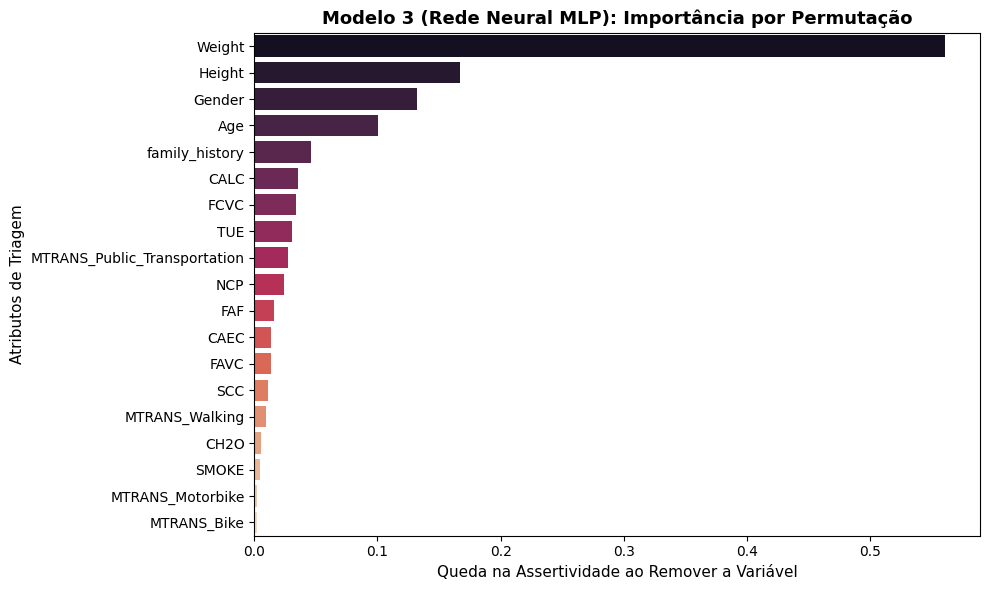

--- [Rede Neural] Top 5 Fatores Mais Determinantes ---
      Atributo  Importancia
        Weight     0.560993
        Height     0.167139
        Gender     0.132151
           Age     0.100236
family_history     0.046099


In [23]:

# Calculando a importância por permutação na Rede Neural usando os dados de teste correspondentes
result_mlp = permutation_importance(model_mlp, X_test_f, y_test_encoded, n_repeats=10, random_state=42, n_jobs=-1)

# O resultado vem como a média da queda da acurácia para cada coluna
df_imp_mlp = pd.DataFrame({'Atributo': X_final.columns, 'Importancia': result_mlp.importances_mean})
df_imp_mlp = df_imp_mlp.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Atributo', data=df_imp_mlp, palette='rocket')
plt.title('Modelo 3 (Rede Neural MLP): Importância por Permutação', fontsize=13, fontweight='bold')
plt.xlabel('Queda na Assertividade ao Remover a Variável', fontsize=11)
plt.ylabel('Atributos de Triagem', fontsize=11)
plt.tight_layout()
plt.show()

print("--- [Rede Neural] Top 5 Fatores Mais Determinantes ---")
print(df_imp_mlp.head(5).to_string(index=False))

Analisando os resultados para determinar qual modelo será utilizado.

In [24]:
print(f"--- Histórico de Comparação Hospitalar ---")
print(f"1. Random Forest: {acuracia_f * 100:.2f}%")
print(f"2. LightGBM:     {acuracia_lgb * 100:.2f}%")
print(f"3. Rede Neural:   {acuracia_mlp * 100:.2f}%\n")

--- Histórico de Comparação Hospitalar ---
1. Random Forest: 95.04%
2. LightGBM:     95.74%
3. Rede Neural:   89.83%



# Modelo escolhido: LightGBM

In [25]:
# Importância dos fatores na triagem

print("--- [LightGBM] Fatores determinantes  ---")
print(df_imp_lgb.head(15).to_string(index=False))

--- [LightGBM] Fatores determinantes  ---
      Atributo  Importancia
        Weight     0.282464
        Height     0.238301
           Age     0.098434
          FCVC     0.065862
           FAF     0.060641
           TUE     0.060401
          CH2O     0.059443
           NCP     0.042631
          CAEC     0.018585
          CALC     0.014945
        Gender     0.014035
          FAVC     0.013029
family_history     0.011065
           SCC     0.008814
MTRANS_Walking     0.005317


### Gerando uma base para utilizar no PowerBI

In [26]:
# Criando a base para o PowerBi

# Vamos pegar a base original
df_powerbi = df.copy()

# Garantir que não há espaços invisíveis nos nomes das colunas
df_powerbi.columns = df_powerbi.columns.str.strip()

# Incluindo as melhorias de engenharia

# Calculando o IMC para criar os filtros e cartões médicos
df_powerbi['IMC'] = df_powerbi['Weight'] / (df_powerbi['Height'] ** 2)

# Corrigindo o nome da coluna de tecnologia de TUE para o padrão do dicionário, se quiser organizar
df_powerbi = df_powerbi.rename(columns={'TUE': 'Tempo_Tela'})

# Exportar para um arquivo único com codificação UTF-8

# O argumento index=False evita que o Pandas crie uma coluna de números sem sentido no Power BI
df_powerbi.to_csv('Obesity_Clean_PowerBI.csv', index=False, encoding='utf-8-sig')

print("✅ Arquivo 'Obesity_Clean_PowerBI.csv' gerado com absoluto sucesso!")

✅ Arquivo 'Obesity_Clean_PowerBI.csv' gerado com absoluto sucesso!


### Gerando o arquivo .pkl para utilizar no Streamlit

In [27]:
import pickle

# Criando o dicionário de artefatos do LightGBM
# Salvamos o modelo e a lista de colunas exatamente na ordem necessária para o deploy
artefatos_deploy = {
    'modelo': model_lgb,                       # O nosso modelo LightGBM com 95.74% de acerto
    'colunas_treino': X_final.columns.tolist() # A lista exata das variáveis na ordem correta
}

# Salvando no arquivo físico
with open('modelo_obesidade.pkl', 'wb') as arquivo:
    pickle.dump(artefatos_deploy, arquivo)

print("🚀 Artefato de Deploy gerado com sucesso!")
print("O arquivo 'modelo_obesidade.pkl' está pronto para ser carregado no seu app do Streamlit!")

🚀 Artefato de Deploy gerado com sucesso!
O arquivo 'modelo_obesidade.pkl' está pronto para ser carregado no seu app do Streamlit!
